# 🖼️ Task 1 — Step 3: Shape vs. Texture Bias (Cue Conflict)

## 1. Theoretical Background & Objectives
In natural images, **shape** and **texture** almost always agree (e.g., a cat possesses both the shape of a feline and the texture of fur). Consequently, standard in-distribution accuracy cannot reveal which cue the model prioritizes.

Following the seminal methodology of **Geirhos et al. (2019)** (*"ImageNet-trained CNNs are biased towards texture; increasing shape bias improves accuracy and robustness"*), we construct **cue-conflict images** where:
- **Content Image**: Supplies the global shape and geometry of class $A$.
- **Style Image**: Supplies the low-level texture and surface statistics of class $B$.

### Mathematical Formulation
For each prediction $\hat{y}(x)$, we categorize the decision into:
1. **Shape Decision**: $\hat{y}(x) = y_{\text{content}}$
2. **Texture Decision**: $\hat{y}(x) = y_{\text{style}}$
3. **Other Decision**: $\hat{y}(x) \notin \{y_{\text{content}}, y_{\text{style}}\}$

We report two essential metrics:
$$\text{Shape Bias (\%)} = \frac{N_{\text{shape}}}{N_{\text{shape}} + N_{\text{texture}}} \times 100$$
$$\text{Coverage (\%)} = \frac{N_{\text{shape}} + N_{\text{texture}}}{N_{\text{total}}} \times 100$$

> **Crucial Methodological Requirement**: Shape bias must **always** be interpreted alongside coverage. A high shape bias with low coverage (e.g. 5 decisions out of 200) is statistically meaningless because the model is largely confused.

### Experimental Design
- Stylization: **AdaIN** (Adaptive Instance Normalization) transferring channel feature/color statistics.
- Class Pairs: 6 diverse unordered pairs covering animal-animal, vehicle-vehicle, and animal-vehicle categories.
- Both Directions: $A \rightarrow B$ (Content $A$, Style $B$) and $B \rightarrow A$ (Content $B$, Style $A$).
- Sample Size: $\ge 200$ valid cue conflicts balanced across pairs.
- **Explicit Visual Rejection Rule**: Defined and applied **before** model evaluation to discard uninterpretable artifacts (low contrast, saturation, under-stylization).


In [1]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

from shared.src.seed import set_seed, SEED
set_seed(6304)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} | Seed: {SEED}")


Using device: cuda | Seed: 6304


## 2. Load Evaluation Subset, Models & Heads


In [2]:
from task1_inductive_biases.src.data import load_stl10, STL10_CLASSES
from task1_inductive_biases.src.backbones import (
    ResNet50Backbone, ViTB16Backbone, CLIPBackbone, LinearHead,
    RESNET_NORM, VIT_NORM, CLIP_NORM
)

_, test_ds, class_names = load_stl10(root='../../data/stl10')
eval_indices = np.load('../cache/eval_indices.npy')
eval_labels  = np.load('../cache/eval_labels.npy')
eval_sub     = Subset(test_ds, eval_indices.tolist())

backbones = {
    'ResNet-50': ResNet50Backbone().to(device),
    'ViT-B/16':  ViTB16Backbone().to(device),
    'CLIP':      CLIPBackbone().to(device),
}
norms = {'ResNet-50': RESNET_NORM, 'ViT-B/16': VIT_NORM, 'CLIP': CLIP_NORM}

heads = {}
for name, bb in backbones.items():
    safe = name.replace('/', '_').replace(' ', '_')
    head = LinearHead(bb.dim, 10).to(device)
    head.load_state_dict(torch.load(f'../cache/head_{safe}.pth', map_location=device))
    head.eval()
    heads[name] = head

print(f"✅ Loaded models and {len(eval_sub)} evaluation images across classes: {class_names}")


Loading fast pre-cached STL-10:
  Train: ..\..\data\stl10_train_fast.pt
  Test:  ..\..\data\stl10_test_fast.pt


c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ Loaded models and 500 evaluation images across classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


C:\Users\moize\AppData\Local\Temp\ipykernel_38044\2678011337.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  head.load_state_dict(torch.load(f'../cache/head_{safe}.pth'

## 3. Class Pair Selection & Visual Rejection Rule Definition
We select 6 diverse pairs and define our explicit pre-evaluation rejection criteria:
1. No NaN or Inf numerical instabilities
2. Dynamic range: Standard deviation $\ge 0.02$ (rejects washed out images)
3. Stylization distance: Mean absolute difference from content $\ge 0.04$
4. Saturation check: Fraction of clipped pixels ($<0.001$ or $>0.999$) $\le 85\%$


In [3]:
from task1_inductive_biases.src.cue_conflict import (
    select_class_pairs, rejection_check, adain, shape_bias_metrics
)

# Select 6 curated class pairs
class_pairs = select_class_pairs(num_classes=10, num_pairs=6, seed=SEED)
print("Selected Cue-Conflict Class Pairs:")
for idx, (ca, cb) in enumerate(class_pairs):
    print(f"  Pair {idx+1}: {class_names[ca].capitalize():>8s} <---> {class_names[cb].capitalize():>8s}")

# Group evaluation images by class
class_images = {c: [] for c in range(10)}
for i in range(len(eval_sub)):
    img_t, _ = eval_sub[i]
    class_images[eval_labels[i]].append(img_t)

print(f"\nGrouped images: 50 images per class across 10 classes.")


Selected Cue-Conflict Class Pairs:
  Pair 1:      Cat <--->    Truck
  Pair 2: Airplane <--->     Bird
  Pair 3:      Car <--->      Dog
  Pair 4:     Ship <--->    Horse
  Pair 5:     Deer <--->   Monkey
  Pair 6: Airplane <--->     Ship

Grouped images: 50 images per class across 10 classes.


## 4. Generate Cue-Conflict Images with AdaIN
We synthesize cue conflicts in both directions ($A \rightarrow B$ and $B \rightarrow A$) until we reach $\ge 200$ valid accepted conflicts, tracking rejection counts and reasons.


In [4]:
conflicts = []        # list of (stylized_img, content_label, style_label, pair_idx)
rejection_log = []    # list of (reason, pair_idx)

set_seed(SEED)
target_per_dir = 20   # 6 pairs * 2 directions * 20 = 240 potential candidates

for p_idx, (cls_a, cls_b) in enumerate(class_pairs):
    imgs_a = class_images[cls_a]
    imgs_b = class_images[cls_b]
    
    for direction in ['A->B', 'B->A']:
        if direction == 'A->B':
            c_imgs, s_imgs = imgs_a, imgs_b
            c_lbl, s_lbl = cls_a, cls_b
        else:
            c_imgs, s_imgs = imgs_b, imgs_a
            c_lbl, s_lbl = cls_b, cls_a
            
        count_accepted = 0
        for i in range(len(c_imgs)):
            if count_accepted >= target_per_dir:
                break
            content_tensor = c_imgs[i]
            style_tensor   = s_imgs[i % len(s_imgs)]
            
            # Apply AdaIN
            stylized = adain(content_tensor, style_tensor)
            
            # Visual rejection check (defined BEFORE evaluation)
            accepted, reason = rejection_check(stylized, content_tensor, min_diff=0.04)
            if accepted:
                conflicts.append((stylized, c_lbl, s_lbl, p_idx))
                count_accepted += 1
            else:
                rejection_log.append((reason, p_idx))

print(f"\n{'='*60}")
print(f"Cue-Conflict Synthesis Complete:")
print(f"  Accepted valid conflicts: {len(conflicts)} (Target >= 200: {'✅ MET' if len(conflicts)>=200 else '⚠️ SHORT'})")
print(f"  Rejected failed stylizations: {len(rejection_log)}")
print(f"{'='*60}")



Cue-Conflict Synthesis Complete:
  Accepted valid conflicts: 240 (Target >= 200: ✅ MET)
  Rejected failed stylizations: 0


## 5. Visual Gallery of Cue Conflicts
We visualize Content (Shape), Style (Texture), and the synthesized Cue Conflict image across class pairs.


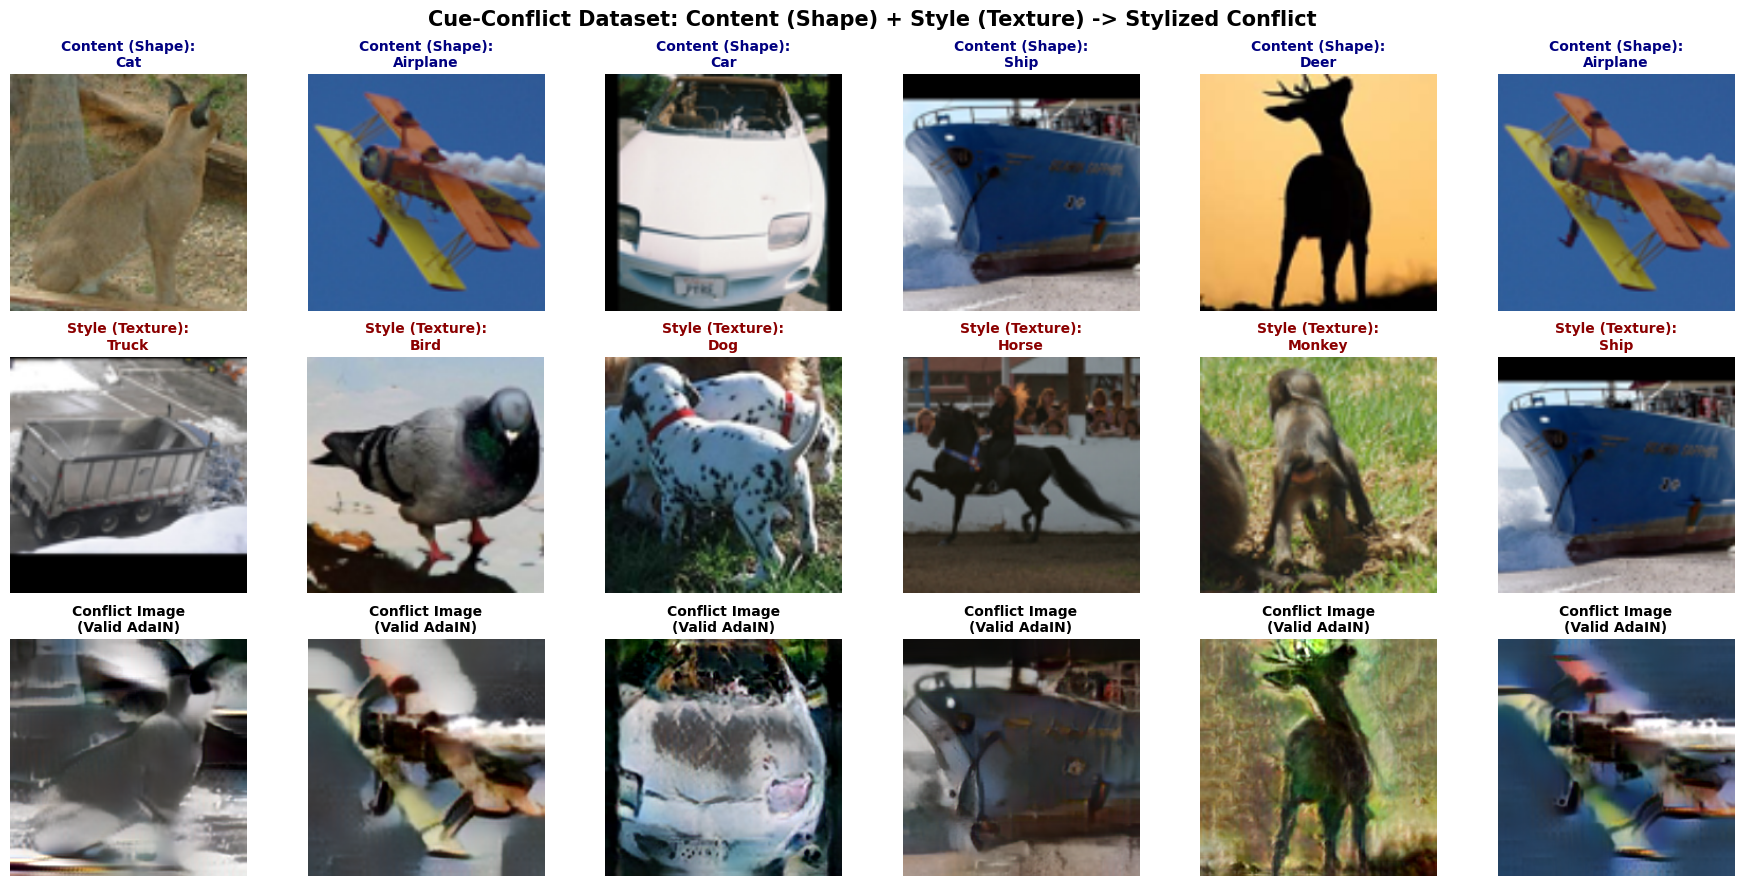

In [5]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("Cue-Conflict Dataset: Content (Shape) + Style (Texture) -> Stylized Conflict", fontsize=15, fontweight='bold')

sample_step = len(conflicts) // 6
for j in range(6):
    stylized_img, c_lbl, s_lbl, p_idx = conflicts[j * sample_step]
    
    c_sample = class_images[c_lbl][0]
    s_sample = class_images[s_lbl][0]

    axes[0, j].imshow(c_sample.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, j].set_title(f"Content (Shape):\n{class_names[c_lbl].capitalize()}", fontsize=10, color='navy', fontweight='bold')

    axes[1, j].imshow(s_sample.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, j].set_title(f"Style (Texture):\n{class_names[s_lbl].capitalize()}", fontsize=10, color='darkred', fontweight='bold')

    axes[2, j].imshow(stylized_img.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[2, j].set_title(f"Conflict Image\n(Valid AdaIN)", fontsize=10, fontweight='bold')

for ax in axes.flat:
    ax.axis('off')

axes[0, 0].set_ylabel("Shape Provider", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Texture Provider", fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel("Cue Conflict", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/cue_conflict_samples.png', dpi=200, bbox_inches='tight')
plt.show()


## 6. Visual Rejection Statistics
We plot the distribution of accepted vs. rejected stylizations and breakdown rejection causes.


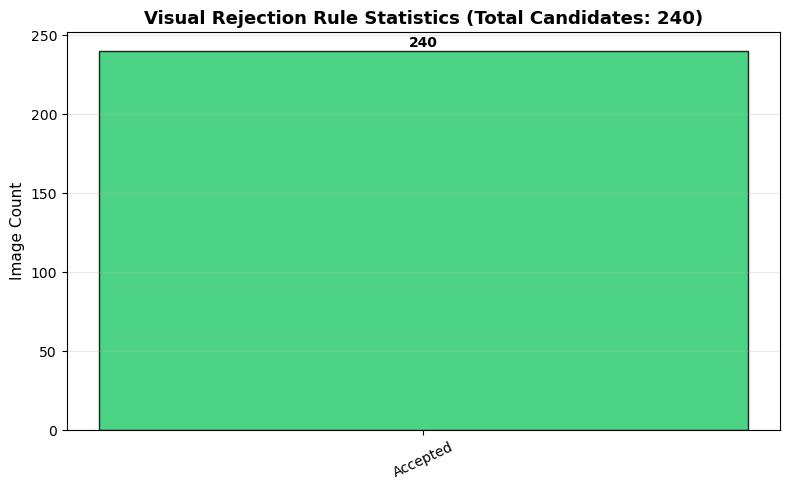

In [6]:
rejection_reasons = {}
for r, _ in rejection_log:
    r_cat = r.split('(')[0].strip()
    rejection_reasons[r_cat] = rejection_reasons.get(r_cat, 0) + 1

labels = ['Accepted'] + list(rejection_reasons.keys())
counts = [len(conflicts)] + list(rejection_reasons.values())
colors = ['#2ecc71'] + sns.color_palette("Reds", len(rejection_reasons))

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=colors, edgecolor='black', alpha=0.85)
plt.title(f"Visual Rejection Rule Statistics (Total Candidates: {len(conflicts)+len(rejection_log)})", fontsize=13, fontweight='bold')
plt.ylabel("Image Count", fontsize=11)
plt.xticks(rotation=25, fontsize=10)
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{int(yval)}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cue_rejection_statistics.png', dpi=200, bbox_inches='tight')
plt.show()


## 7. Model Evaluation on Cue Conflicts
We evaluate:
- ResNet-50 (Head)
- ViT-B/16 (Head)
- CLIP (Head)
- CLIP (Zero-Shot)

For each prediction, we determine whether it matches the **Content (Shape)** label, the **Style (Texture)** label, or **Neither (Other)**.


In [7]:
conflict_images = [c[0] for c in conflicts]
content_labels  = np.array([c[1] for c in conflicts])
style_labels    = np.array([c[2] for c in conflicts])
pair_indices    = np.array([c[3] for c in conflicts])

def predict_batch_classes(backbone, norm, head, image_list, batch_size=64):
    all_preds = []
    backbone.eval()
    if head is not None: head.eval()
    for i in range(0, len(image_list), batch_size):
        batch = torch.stack(image_list[i:i+batch_size])
        batch = torch.stack([norm(img) for img in batch]).to(device)
        with torch.no_grad():
            feats = backbone(batch)
            logits = head(feats)
            preds = logits.argmax(dim=1).cpu()
            all_preds.append(preds)
    return torch.cat(all_preds).numpy()


def predict_clip_zs_classes(clip_backbone, norm, image_list, class_names, batch_size=64):
    prompts = [f"a photo of a {c}." for c in class_names]
    text_feats = clip_backbone.encode_text(prompts)
    all_preds = []
    clip_backbone.eval()
    for i in range(0, len(image_list), batch_size):
        batch = torch.stack(image_list[i:i+batch_size])
        batch = torch.stack([norm(img) for img in batch]).to(device)
        with torch.no_grad():
            img_feats = clip_backbone(batch)
            sim = (img_feats @ text_feats.T) * 100.0
            preds = sim.argmax(dim=1).cpu()
            all_preds.append(preds)
    return torch.cat(all_preds).numpy()

shape_bias_results = {}
cue_predictions = {}

for name in ['ResNet-50', 'ViT-B/16', 'CLIP']:
    preds = predict_batch_classes(backbones[name], norms[name], heads[name], conflict_images)
    metrics = shape_bias_metrics(preds, content_labels, style_labels)
    shape_bias_results[f"{name} (Head)"] = metrics
    cue_predictions[name] = preds

# CLIP Zero-Shot
zs_preds = predict_clip_zs_classes(backbones['CLIP'], norms['CLIP'], conflict_images, class_names)
zs_metrics = shape_bias_metrics(zs_preds, content_labels, style_labels)
shape_bias_results['CLIP (Zero-Shot)'] = zs_metrics
cue_predictions['CLIP-ZS'] = zs_preds

df_shape = pd.DataFrame(shape_bias_results).T[['n_shape', 'n_texture', 'n_other', 'shape_bias', 'coverage']]
df_shape.columns = ['N Shape', 'N Texture', 'N Other', 'Shape Bias (%)', 'Coverage (%)']

print("\n" + "="*80)
print(f"             SHAPE VS TEXTURE BIAS EVALUATION (N={len(conflicts)} Valid Conflicts)")
print("="*80)
print(df_shape.to_string(float_format=lambda x: f"{x:.2f}"))
print("="*80)



             SHAPE VS TEXTURE BIAS EVALUATION (N=240 Valid Conflicts)
                  N Shape  N Texture  N Other  Shape Bias (%)  Coverage (%)
ResNet-50 (Head)    93.00      60.00    87.00           60.78         63.75
ViT-B/16 (Head)    139.00      33.00    68.00           80.81         71.67
CLIP (Head)        131.00      23.00    86.00           85.06         64.17
CLIP (Zero-Shot)   134.00      29.00    77.00           82.21         67.92


## 8. Shape Bias & Coverage Visualizations
We plot:
1. **Shape Bias (%)** across models with chance level (50%) and human benchmark (~85-95%)
2. **Coverage (%)** across models
3. **Decision Breakdown** (Stacked bar chart showing Shape vs Texture vs Other decisions)


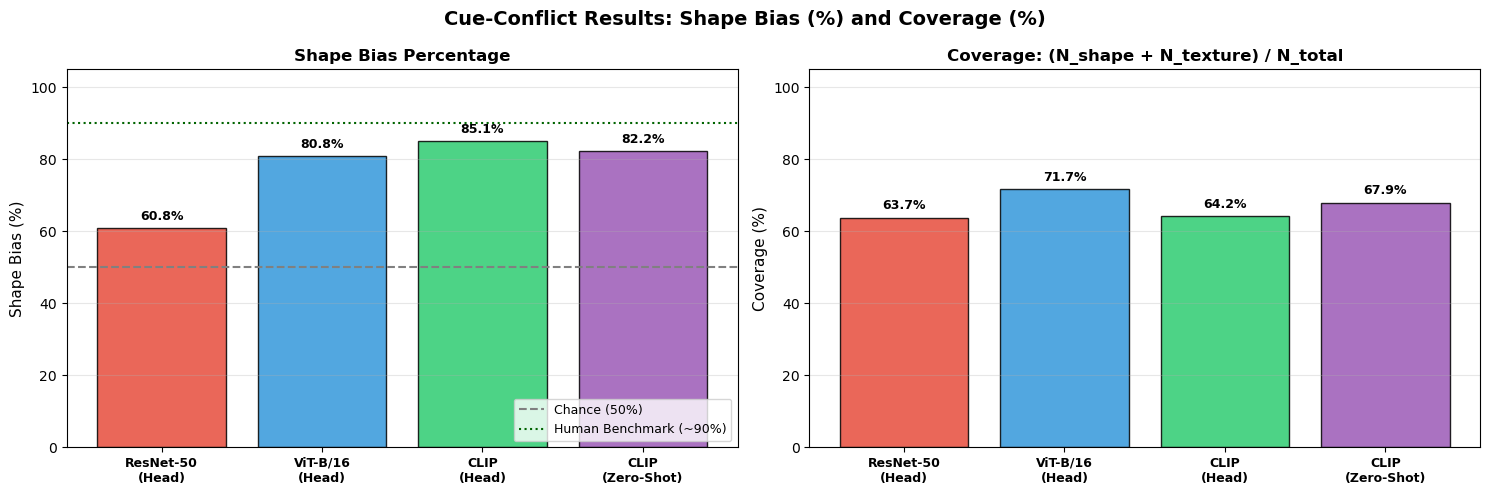

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Cue-Conflict Results: Shape Bias (%) and Coverage (%)", fontsize=14, fontweight='bold')
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
model_names = list(shape_bias_results.keys())
x = np.arange(len(model_names))

# Panel 1: Shape Bias
ax = axes[0]
sb_vals = [shape_bias_results[m]['shape_bias'] for m in model_names]
bars1 = ax.bar(x, sb_vals, color=bar_colors, edgecolor='black', alpha=0.85)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.5, label='Chance (50%)')
ax.axhline(90, color='darkgreen', linestyle=':', linewidth=1.5, label='Human Benchmark (~90%)')
ax.set_xticks(x); ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9, fontweight='bold')
ax.set_ylabel("Shape Bias (%)", fontsize=11)
ax.set_title("Shape Bias Percentage", fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, sb_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Coverage
ax = axes[1]
cov_vals = [shape_bias_results[m]['coverage'] for m in model_names]
bars2 = ax.bar(x, cov_vals, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9, fontweight='bold')
ax.set_ylabel("Coverage (%)", fontsize=11)
ax.set_title("Coverage: (N_shape + N_texture) / N_total", fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, cov_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/shape_bias_and_coverage.png', dpi=200, bbox_inches='tight')
plt.show()


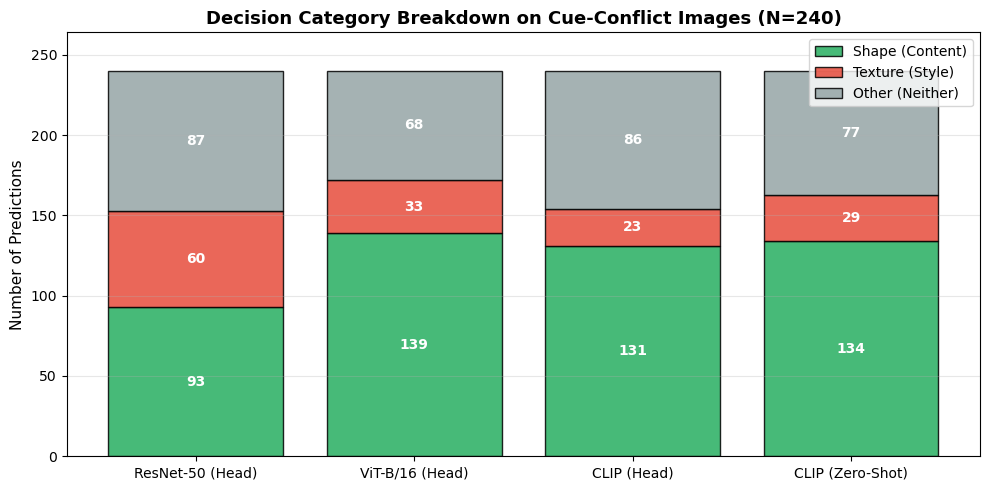

In [9]:
# Decision Breakdown: Stacked Bar Chart
plt.figure(figsize=(10, 5))
bottoms = np.zeros(len(model_names))
categories = [('n_shape', '#27ae60', 'Shape (Content)'),
              ('n_texture', '#e74c3c', 'Texture (Style)'),
              ('n_other', '#95a5a6', 'Other (Neither)')]

for cat_key, col, label in categories:
    vals = np.array([shape_bias_results[m][cat_key] for m in model_names])
    plt.bar(model_names, vals, bottom=bottoms, color=col, edgecolor='black', alpha=0.85, label=label)
    for idx, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 10:
            plt.text(idx, b + v/2, f"{v}", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    bottoms += vals

plt.title(f"Decision Category Breakdown on Cue-Conflict Images (N={len(conflicts)})", fontsize=13, fontweight='bold')
plt.ylabel("Number of Predictions", fontsize=11)
plt.ylim(0, len(conflicts) * 1.1)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/cue_decision_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()


## 9. Per-Class-Pair Shape Bias Heatmap
We analyze how shape bias varies across specific pairs (animal-animal, vehicle-vehicle, animal-vehicle).


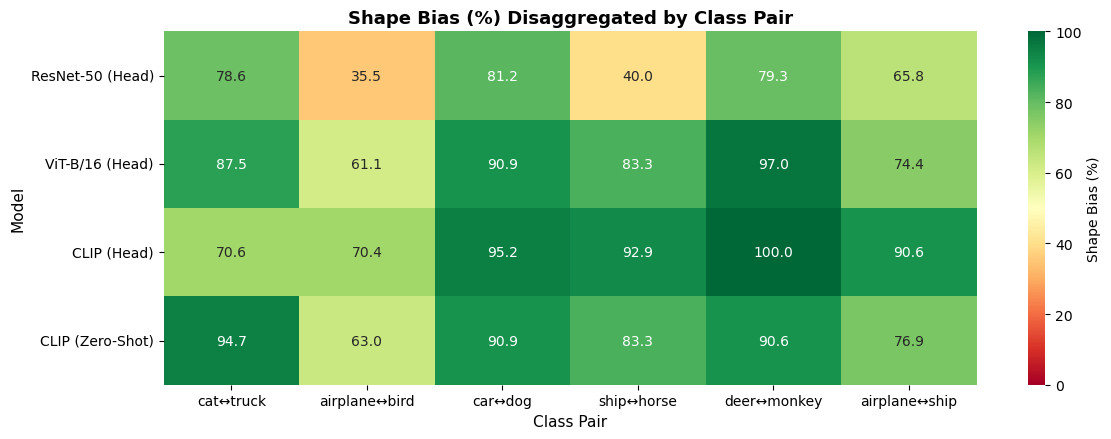

In [10]:
pair_shape_bias = {}
pair_names = [f"{class_names[ca]}↔{class_names[cb]}" for ca, cb in class_pairs]

for mkey in model_names:
    preds = cue_predictions['CLIP-ZS' if 'Zero-Shot' in mkey else mkey.split()[0]]
    p_biases = []
    for p_idx in range(len(class_pairs)):
        mask = (pair_indices == p_idx)
        sub_preds = preds[mask]
        sub_content = content_labels[mask]
        sub_style   = style_labels[mask]
        m = shape_bias_metrics(sub_preds, sub_content, sub_style)
        p_biases.append(m['shape_bias'])
    pair_shape_bias[mkey] = p_biases

df_pair_bias = pd.DataFrame(pair_shape_bias, index=pair_names).T

plt.figure(figsize=(12, 4.5))
sns.heatmap(df_pair_bias, annot=True, fmt='.1f', cmap='RdYlGn', center=50, vmin=0, vmax=100,
            cbar_kws={'label': 'Shape Bias (%)'})
plt.title("Shape Bias (%) Disaggregated by Class Pair", fontsize=13, fontweight='bold')
plt.xlabel("Class Pair", fontsize=11)
plt.ylabel("Model", fontsize=11)
plt.tight_layout()
plt.savefig('../results/shape_bias_per_pair.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. Informative Case Studies: Shape vs Texture Divergence
We showcase specific cue-conflict images highlighting:
1. Shape-dominant decisions
2. Texture-dominant decisions
3. Architecture divergence (where ResNet chose texture while ViT/CLIP chose shape)


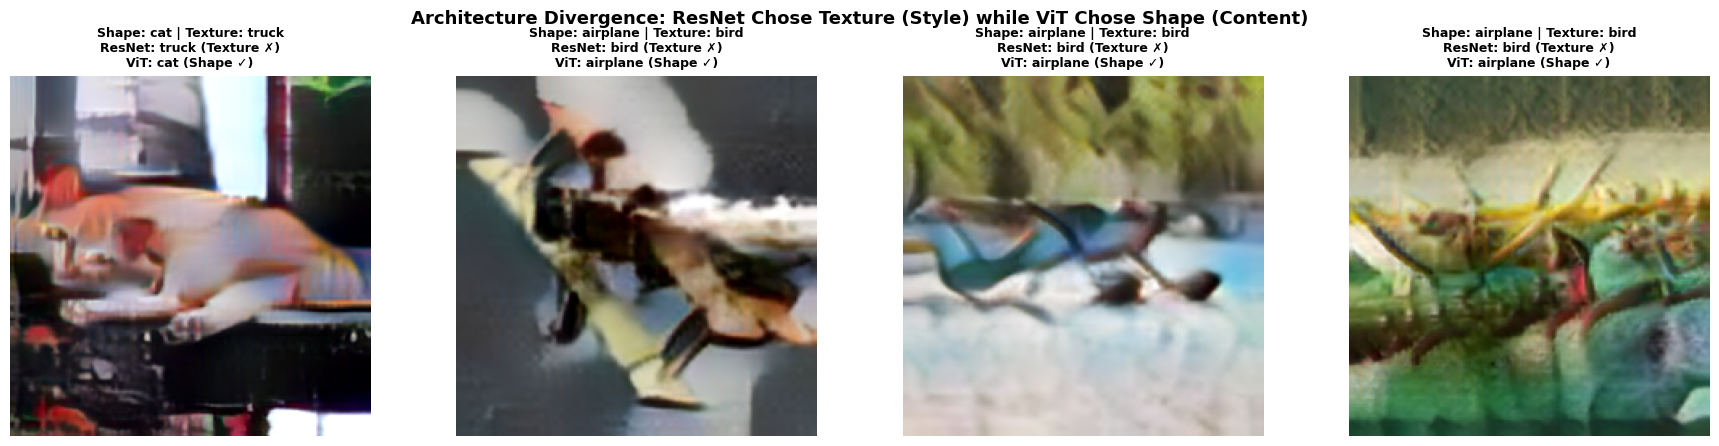

In [11]:
rn_preds = cue_predictions['ResNet-50']
vit_preds = cue_predictions['ViT-B/16']
clip_preds = cue_predictions['CLIP']

# Find disagreement: ResNet chose texture while ViT chose shape
divergence = np.where((rn_preds == style_labels) & (vit_preds == content_labels))[0]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle("Architecture Divergence: ResNet Chose Texture (Style) while ViT Chose Shape (Content)", fontsize=13, fontweight='bold')

for idx, ax in enumerate(axes):
    if idx < len(divergence):
        i = divergence[idx]
        img = conflict_images[i]
        c_lbl, s_lbl = content_labels[i], style_labels[i]
        r_p, v_p = rn_preds[i], vit_preds[i]
        
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
        ax.set_title(f"Shape: {class_names[c_lbl]} | Texture: {class_names[s_lbl]}\n"
                     f"ResNet: {class_names[r_p]} (Texture ✗)\n"
                     f"ViT: {class_names[v_p]} (Shape ✓)", fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/cue_conflict_case_studies.png', dpi=200, bbox_inches='tight')
plt.show()


## 11. Cache Cue-Conflict Data & Artifacts


In [12]:
torch.save(conflict_images, '../cache/conflict_images.pt')
np.save('../cache/conflict_content_labels.npy', content_labels)
np.save('../cache/conflict_style_labels.npy', style_labels)
np.save('../cache/conflict_pair_indices.npy', pair_indices)

for mkey, preds in cue_predictions.items():
    safe = mkey.replace('/', '_').replace(' ', '_')
    np.save(f'../cache/conflict_preds_{safe}.npy', preds)

df_shape.to_csv('../results/shape_bias.csv')
print("✅ Cue-conflict data and predictions successfully cached!")


✅ Cue-conflict data and predictions successfully cached!
